In [2]:
from matplotlib import colors
from matplotlib import pyplot as plt
from astropy.table import Table
import numpy as np
import os
import pandas as pd
import pathlib
import polars as pl

In [3]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [ ]:
gaiaids = pl.read_parquet('(#path to#)allgaiadata.parq').to_pandas()

In [ ]:
reportedsample = pd.read_csv('(#path to#)reportable.csv', index_col='Unnamed: 0')

In [6]:
reportedsample['bp-rp'] = reportedsample['phot_bp_mean_mag']-reportedsample['phot_rp_mean_mag']

In [7]:
minra = np.nanmin(gaiaids['ra_rad'].values)
maxra = np.nanmax(gaiaids['ra_rad'].values)
mindec = np.nanmin(gaiaids['dec_rad'].values)
maxdec = np.nanmax(gaiaids['dec_rad'].values)
allbins, allx, ally = np.histogram2d(gaiaids['ra_rad'],gaiaids['dec_rad'],bins=200,range=[[minra,maxra],[mindec,maxdec]])
prebins, px, py = np.histogram2d(reportedsample['ra_rad'],reportedsample['dec_rad'], bins=200,range=[[minra,maxra],[mindec,maxdec]])
totdet_fracradec = prebins/allbins

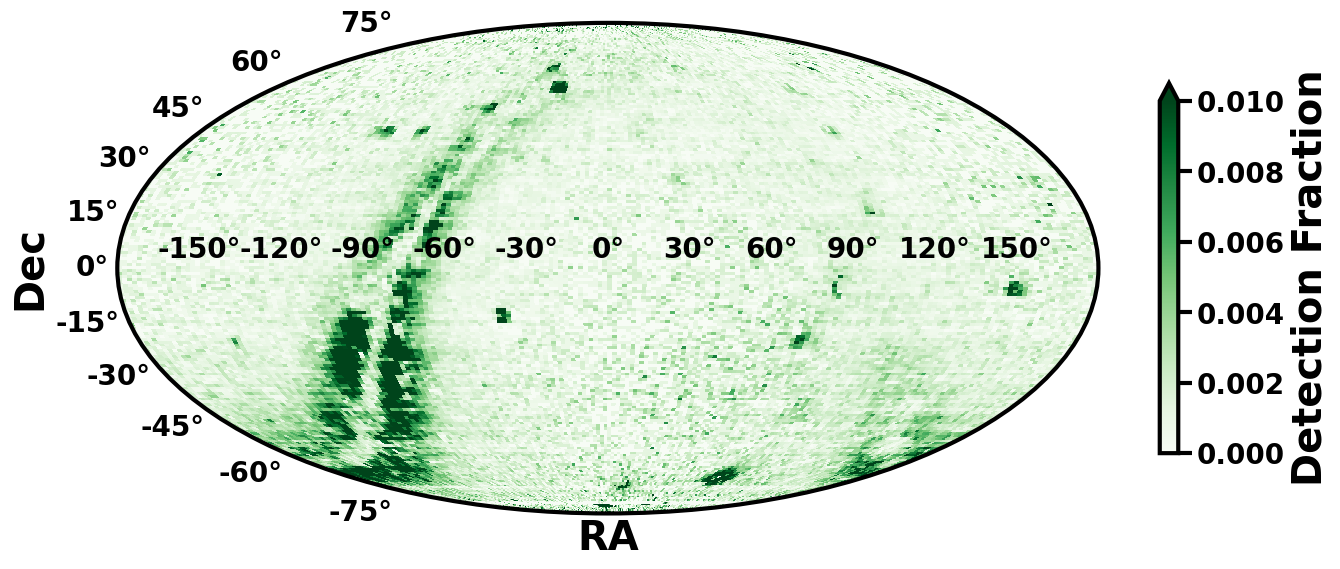

In [17]:
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='mollweide')
cmap = plt.cm.Greens
ax.pcolor(
    allx, ally,
    totdet_fracradec.T, cmap=cmap, shading='auto', vmin=0, vmax=0.01, rasterized=True)
cbar = plt.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(0, 0.01), cmap=cmap), ax=ax, shrink=0.5,  extend='max')
cbar.set_label("Detection Fraction")
ax.set_ylabel('Dec')
ax.set_xlabel('RA')
plt.tight_layout()
plt.savefig('mollweide_detfraction.pdf', dpi=300)
plt.show()

In [8]:
gaiaids['bp-rp'] = gaiaids['phot_bp_mean_mag'] - gaiaids['phot_rp_mean_mag']

In [50]:
minbprp = np.nanmin(gaiaids['bp-rp'].values)
maxbprp = np.nanmax(gaiaids['bp-rp'].values)
mingmag = np.nanmin(gaiaids['abs_g_mag'].values)
maxgmag = np.nanmax(gaiaids['abs_g_mag'].values)
allbins, allx, ally = np.histogram2d(gaiaids['bp-rp'],gaiaids['abs_g_mag'],bins=500,range=[[minbprp,maxbprp],[mingmag,maxgmag]])
prebins, px, py = np.histogram2d(reportedsample['bp-rp'], reportedsample['abs_g_mag'], bins=500,range=[[minbprp,maxbprp],[mingmag,maxgmag]])
totdet_fracradec = prebins/allbins

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_61980/727919096.py:7: RuntimeWarning: invalid value encountered in divide
  totdet_fracradec = prebins/allbins


/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_61980/1921475122.py:5: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  cbar = fig.colorbar(chehe, ax=ax)


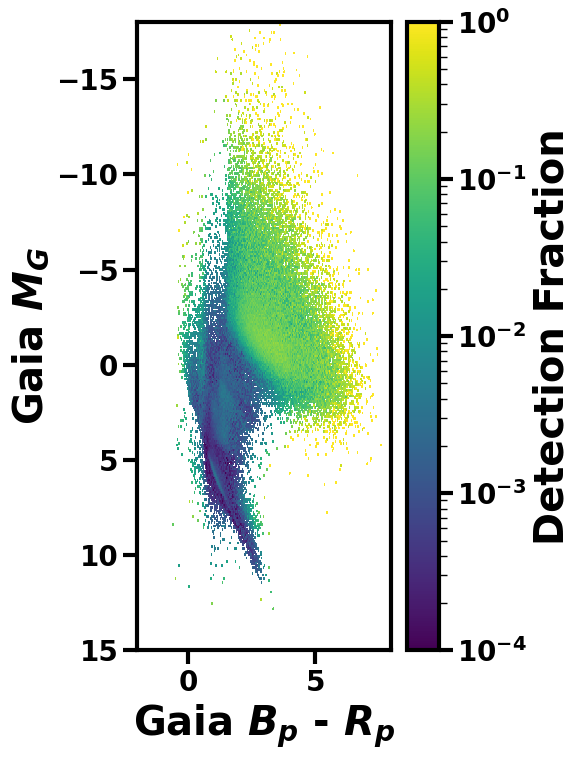

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(6, 8))
cmap = plt.cm.viridis_r
ax.set(xlim=(-2, 8), ylim=(15, -18), xlabel='Gaia $B_p$ - $R_p$', ylabel=f'Gaia $M_G$')
chehe = ax.pcolor(allx, ally, totdet_fracradec.T, shading='auto', norm=colors.LogNorm(vmin=0.0001, vmax=1), rasterized=True)
cbar = fig.colorbar(chehe, ax=ax)
cbar.set_label("Detection Fraction")
plt.tight_layout()
plt.savefig('hr_detfraction.pdf', dpi=300)
plt.show()